# 배치 정규화
- 학습 중간값을 정규화하는 레이어
- 학습이 안정적이고 빨라짐
- 과적합 억제
- 초기화 의존 적음
- 레이어 중간값에 대해 각 피처별로 정규화 
    - $$\hat x = \frac{x-\mu}{\sqrt \sigma + \epsilon}$$
- 학습가능한 스케일링과 이동 
    - $$y = \gamma \hat x + \beta$$

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from datasets.mnist import load_mnist
from b1.module.multi_layer_net_extend import MultiLayerNetExtend
from b1.module.optimizer import SGD, Adam

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, one_hot_label=True)

# 학습 데이터를 줄임
x_train = x_train[:1000]
t_train = t_train[:1000]

max_epochs = 20
train_size = x_train.shape[0]
batch_size = 100
learning_rate = 0.01


def __train(weight_init_std):
    bn_network = MultiLayerNetExtend(
        input_size=784,
        hidden_size_list=[100, 100, 100, 100, 100],
        output_size=10,
        weight_init_std=weight_init_std,
        use_batchnorm=True,
    )
    network = MultiLayerNetExtend(
        input_size=784,
        hidden_size_list=[100, 100, 100, 100, 100],
        output_size=10,
        weight_init_std=weight_init_std,
    )
    optimizer = SGD(lr=learning_rate)

    train_acc_list = []
    bn_train_acc_list = []

    iter_per_epoch = max(train_size / batch_size, 1)
    epoch_cnt = 0

    for i in range(1000000000):
        batch_mask = np.random.choice(train_size, batch_size)
        x_batch = x_train[batch_mask]
        t_batch = t_train[batch_mask]

        for _network in (bn_network, network):
            grads = _network.gradient(x_batch, t_batch)
            optimizer.update(_network.params, grads)

        if i % iter_per_epoch == 0:
            train_acc = network.accuracy(x_train, t_train)
            bn_train_acc = bn_network.accuracy(x_train, t_train)
            train_acc_list.append(train_acc)
            bn_train_acc_list.append(bn_train_acc)

            print(
                "epoch:"
                + str(epoch_cnt)
                + " | "
                + str(train_acc)
                + " - "
                + str(bn_train_acc)
            )

            epoch_cnt += 1
            if epoch_cnt >= max_epochs:
                break

    return train_acc_list, bn_train_acc_list

============== 1/16 ==============
epoch:0 | 0.099 - 0.132
epoch:1 | 0.097 - 0.103
epoch:2 | 0.097 - 0.118
epoch:3 | 0.097 - 0.129
epoch:4 | 0.097 - 0.141
epoch:5 | 0.097 - 0.17
epoch:6 | 0.097 - 0.194
epoch:7 | 0.097 - 0.22
epoch:8 | 0.097 - 0.234
epoch:9 | 0.097 - 0.25
epoch:10 | 0.097 - 0.271
epoch:11 | 0.097 - 0.285
epoch:12 | 0.097 - 0.295
epoch:13 | 0.097 - 0.315
epoch:14 | 0.097 - 0.33
epoch:15 | 0.097 - 0.352
epoch:16 | 0.097 - 0.365
epoch:17 | 0.097 - 0.374
epoch:18 | 0.097 - 0.391
epoch:19 | 0.097 - 0.401
============== 2/16 ==============
epoch:0 | 0.1 - 0.06


/tmp/ipykernel_187753/2700342042.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


epoch:1 | 0.097 - 0.091
epoch:2 | 0.097 - 0.123
epoch:3 | 0.097 - 0.139
epoch:4 | 0.097 - 0.172
epoch:5 | 0.097 - 0.197
epoch:6 | 0.097 - 0.23
epoch:7 | 0.097 - 0.262
epoch:8 | 0.097 - 0.289
epoch:9 | 0.097 - 0.311
epoch:10 | 0.097 - 0.334
epoch:11 | 0.097 - 0.354
epoch:12 | 0.097 - 0.364
epoch:13 | 0.097 - 0.385
epoch:14 | 0.097 - 0.413
epoch:15 | 0.097 - 0.42
epoch:16 | 0.097 - 0.432
epoch:17 | 0.097 - 0.455
epoch:18 | 0.097 - 0.471
epoch:19 | 0.097 - 0.484
============== 3/16 ==============
epoch:0 | 0.147 - 0.065
epoch:1 | 0.356 - 0.08
epoch:2 | 0.459 - 0.113
epoch:3 | 0.601 - 0.144
epoch:4 | 0.655 - 0.206
epoch:5 | 0.745 - 0.26
epoch:6 | 0.775 - 0.299
epoch:7 | 0.803 - 0.336
epoch:8 | 0.84 - 0.376
epoch:9 | 0.868 - 0.4
epoch:10 | 0.909 - 0.429
epoch:11 | 0.908 - 0.475
epoch:12 | 0.933 - 0.499
epoch:13 | 0.938 - 0.511
epoch:14 | 0.948 - 0.542
epoch:15 | 0.96 - 0.562
epoch:16 | 0.962 - 0.594
epoch:17 | 0.971 - 0.616
epoch:18 | 0.979 - 0.631
epoch:19 | 0.984 - 0.647
============== 4/

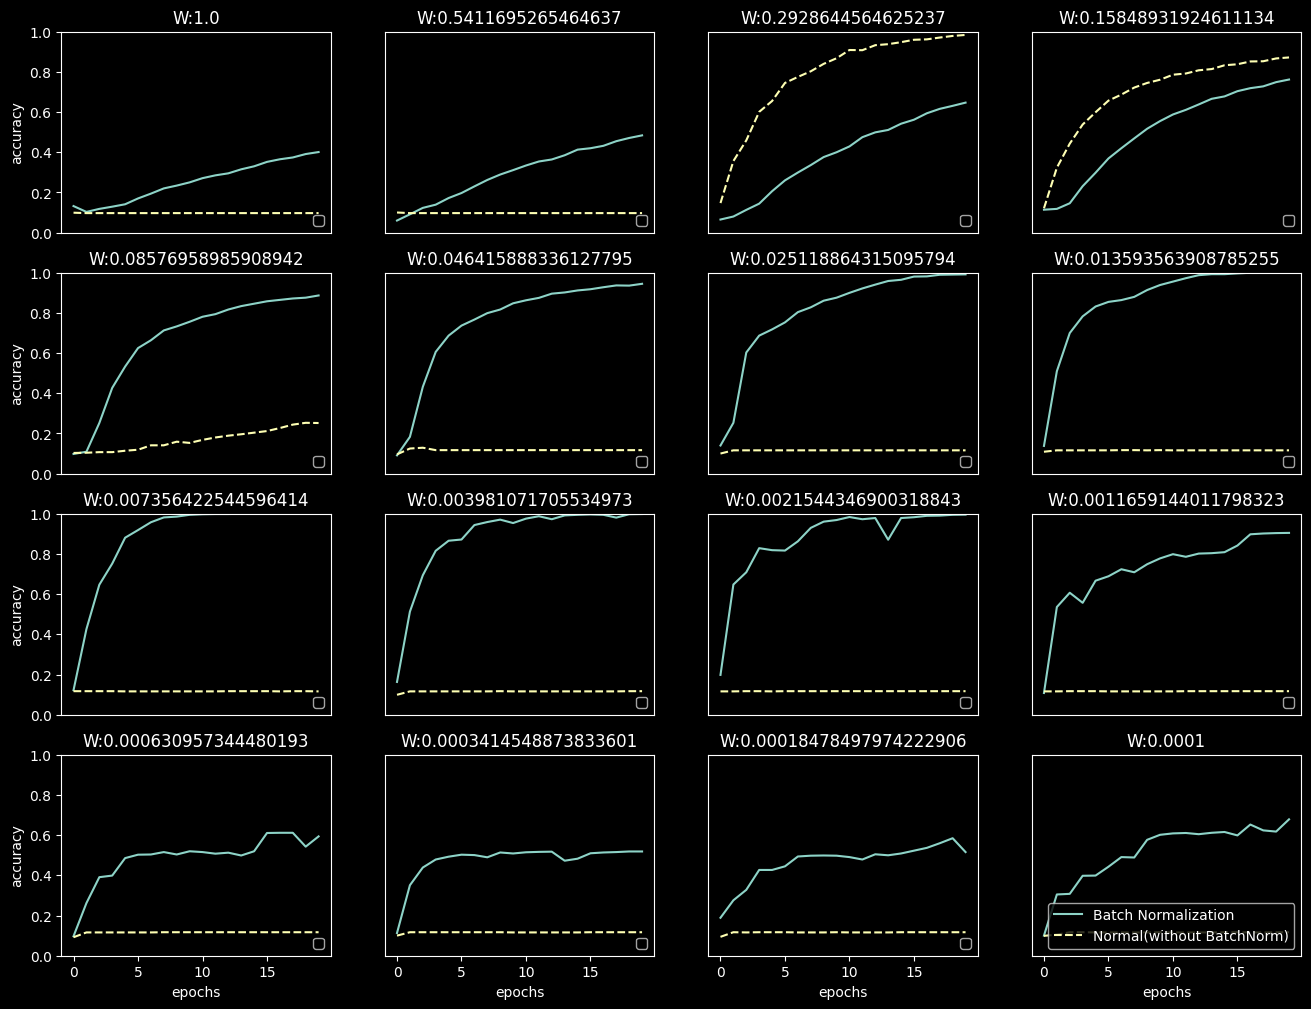

In [ ]:
weight_scale_list = np.logspace(0, -4, num=16)
x = np.arange(max_epochs)

plt.figure(figsize=(16, 12))

for i, w in enumerate(weight_scale_list):
    print("============== " + str(i + 1) + "/16" + " ==============")
    train_acc_list, bn_train_acc_list = __train(w)

    plt.subplot(4, 4, i + 1)
    plt.title("W:" + str(w))
    if i == 15:
        plt.plot(x, bn_train_acc_list, label="Batch Normalization", markevery=2)
        plt.plot(
            x,
            train_acc_list,
            linestyle="--",
            label="Normal(without BatchNorm)",
            markevery=2,
        )
    else:
        plt.plot(x, bn_train_acc_list, markevery=2)
        plt.plot(x, train_acc_list, linestyle="--", markevery=2)

    plt.ylim(0, 1.0)
    if i % 4:
        plt.yticks([])
    else:
        plt.ylabel("accuracy")
    if i < 12:
        plt.xticks([])
    else:
        plt.xlabel("epochs")
    plt.legend(loc="lower right")

plt.show()